**Неуправляемое вращение**

In [52]:
import sympy as sp
q1 = sp.Matrix(sp.symbols('w_1 x_1 y_1 z_1'))
q2 = sp.Matrix(sp.symbols('w_2 x_2 y_2 z_2'))
q1vec = sp.Matrix(q1[1:4])
q2vec = sp.Matrix(q2[1:4])
q0 = q1[0] * q2[0] - q1vec.dot(q2vec)
qvec = q1[0]*q2vec + q2[0]*q1vec + q1vec.cross(q2vec)
print("Произведение кватернионов:")
display(sp.Matrix([q0, qvec]))

Произведение кватернионов:


Matrix([
[w_1*w_2 - x_1*x_2 - y_1*y_2 - z_1*z_2],
[w_1*x_2 + w_2*x_1 + y_1*z_2 - y_2*z_1],
[w_1*y_2 + w_2*y_1 - x_1*z_2 + x_2*z_1],
[w_1*z_2 + w_2*z_1 + x_1*y_2 - x_2*y_1]])

In [61]:
wx, wy, wz = sp.symbols('omega_x omega_y omega_z')
q2 = sp.Matrix(sp.symbols('q_0 x y z'))
q1 = sp.Matrix([0, wx, wy, wz])
q1vec = sp.Matrix(q1[1:4])
q2vec = sp.Matrix(q2[1:4])
q0 = q1[0] * q2[0] - q1vec.dot(q2vec)
qvec = q1[0]*q2vec + q2[0]*q1vec + q1vec.cross(q2vec)
print("ω ○ q:")
display(sp.Matrix([q0, qvec]))

ω ○ q:


Matrix([
[  -omega_x*x - omega_y*y - omega_z*z],
[ omega_x*q_0 + omega_y*z - omega_z*y],
[-omega_x*z + omega_y*q_0 + omega_z*x],
[ omega_x*y - omega_y*x + omega_z*q_0]])

In [63]:
wx, wy, wz = sp.symbols('omega_x omega_y omega_z')
A = sp.Matrix([[0, -wx, -wy, -wz],
               [wx, 0, -wz, wy],
               [wy, wz, 0, -wx],
               [wz, -wy, wx, 0]]) * 1/2
display(A)
P, J = A.jordan_form()
print("Матрица преобразования P:")
display(P)
print("\nЖорданова форма J:")
display(J)

Matrix([
[        0, -omega_x/2, -omega_y/2, -omega_z/2],
[omega_x/2,          0, -omega_z/2,  omega_y/2],
[omega_y/2,  omega_z/2,          0, -omega_x/2],
[omega_z/2, -omega_y/2,  omega_x/2,          0]])

Матрица преобразования P:


Matrix([
[-(-omega_x**2*omega_y + omega_x*omega_z*sqrt(-omega_x**2 - omega_y**2 - omega_z**2) - omega_y**3 - omega_y*omega_z**2)/(omega_y**2*sqrt(-omega_x**2 - omega_y**2 - omega_z**2) + omega_z**2*sqrt(-omega_x**2 - omega_y**2 - omega_z**2)), -(-omega_x**2*omega_z - omega_x*omega_y*sqrt(-omega_x**2 - omega_y**2 - omega_z**2) - omega_y**2*omega_z - omega_z**3)/(omega_y**2*sqrt(-omega_x**2 - omega_y**2 - omega_z**2) + omega_z**2*sqrt(-omega_x**2 - omega_y**2 - omega_z**2)), -(omega_x**2*omega_y + omega_x*omega_z*sqrt(-omega_x**2 - omega_y**2 - omega_z**2) + omega_y**3 + omega_y*omega_z**2)/(omega_y**2*sqrt(-omega_x**2 - omega_y**2 - omega_z**2) + omega_z**2*sqrt(-omega_x**2 - omega_y**2 - omega_z**2)), -(omega_x**2*omega_z - omega_x*omega_y*sqrt(-omega_x**2 - omega_y**2 - omega_z**2) + omega_y**2*omega_z + omega_z**3)/(omega_y**2*sqrt(-omega_x**2 - omega_y**2 - omega_z**2) + omega_z**2*sqrt(-omega_x**2 - omega_y**2 - omega_z**2))],
[                                                      


Жорданова форма J:


Matrix([
[-sqrt(-omega_x**2/4 - omega_y**2/4 - omega_z**2/4),                                                  0,                                                 0,                                                 0],
[                                                 0, -sqrt(-omega_x**2/4 - omega_y**2/4 - omega_z**2/4),                                                 0,                                                 0],
[                                                 0,                                                  0, sqrt(-omega_x**2/4 - omega_y**2/4 - omega_z**2/4),                                                 0],
[                                                 0,                                                  0,                                                 0, sqrt(-omega_x**2/4 - omega_y**2/4 - omega_z**2/4)]])

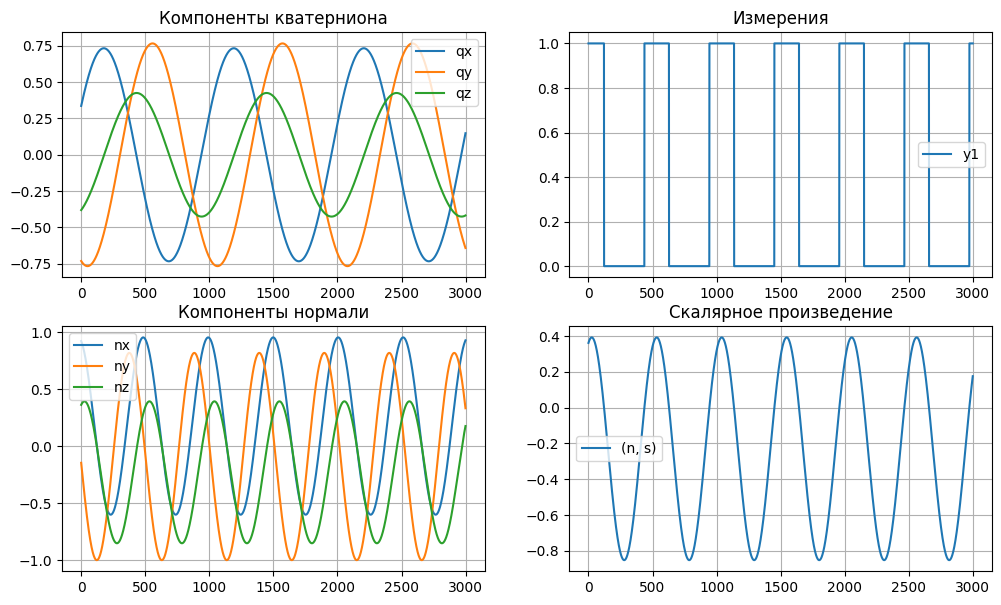

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def qdot(q1,q2):
    q0 = q1[0] * q2[0] - np.dot(q1[1:4], q2[1:4])
    qvec = q1[0]*q2[1:4] + q2[0]*q1[1:4] + np.cross(q1[1:4], q2[1:4])
    return np.append(q0, qvec)

def quat2dcm(q):
    x,y,z,w = q
    return np.array([[1-2*y**2-2*z**2, 2*x*y+2*z*w, 2*x*z-2*y*w],
                     [2*x*y-2*z*w, 1-2*x**2-2*z**2, 2*y*z+2*x*w],
                     [2*x*z+2*y*w, 2*y*w-2*x*w, 1-2*x**2-2*y**2]])

dt = 0.1
t = 300
z = np.array([0, 0, 1])
q = np.random.uniform(-1, 1, 4)
q = q / np.linalg.norm(q)
w = np.random.uniform(-1, 1, 3) * 0.01
s = np.array([0, 0, 1])
w_q = np.append(0, w)

d = pd.DataFrame()
for i in range(round(t / dt)):
    q += 1/2 * qdot(w_q, q)
    q = q / np.linalg.norm(q)
    A = quat2dcm(q)
    n = A @ z
    y = np.dot(n, s)
    d.loc[i, 'nx'] = n[0]
    d.loc[i, 'ny'] = n[1]
    d.loc[i, 'nz'] = n[2]
    d.loc[i, 'qx'] = q[1]
    d.loc[i, 'qy'] = q[2]
    d.loc[i, 'qz'] = q[3]
    d.loc[i, 'y'] = y
    d.loc[i, 'y1'] = int(y > 0)
    d.loc[i, 'y2'] = int(y < 0)

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
for j, c in enumerate('xyz'):
    axs[0][0].plot(d['q'+c], label='q'+c)
axs[0][1].plot(d['y1'], label='y1')
for j, c in enumerate('xyz'):
    axs[1][0].plot(d['n'+c], label='n'+c)
axs[1][1].plot(d['y'], label='(n, s)')
for j in range(2):
    for i in range(2):
        axs[i][j].set_title(["Компоненты кватерниона", "Измерения", "Компоненты нормали", "Скалярное произведение"][j+i*2])
        axs[i][j].legend()
        axs[i][j].grid()
plt.show()